In [161]:
!pip install -q kagglehub
!pip install -q imbalanced-learn
!pip install -q xgboost
!pip install -q shap
!pip install -q sentence-transformers
!pip install -q faiss-cpu
!pip install -q joblib

In [162]:
import os
import glob
import time
import warnings
import joblib

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

from imblearn.over_sampling import SMOTE

warnings.filterwarnings("ignore")

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [163]:
import kagglehub

path = kagglehub.dataset_download(
    "mlg-ulb/creditcardfraud"
)

print("Path to dataset files:", path)

Path to dataset files: /root/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3


In [164]:
import os

print("Files inside downloaded folder:")

for file in os.listdir(path):
    print(file)

Files inside downloaded folder:
creditcard.csv


In [165]:
csv_files = glob.glob(os.path.join(path, "*.csv"))

print(csv_files)

['/root/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv']


In [166]:
csv_path = csv_files[0]

print("Using:", csv_path)

Using: /root/.cache/kagglehub/datasets/mlg-ulb/creditcardfraud/versions/3/creditcard.csv


In [167]:
df = pd.read_csv(csv_path)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [168]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [169]:
df.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [170]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [171]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


In [172]:
print(df.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


In [173]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [174]:
fraud_rate = df["Class"].mean() * 100

print(f"Fraud rate: {fraud_rate:.4f}%")

Fraud rate: 0.1727%


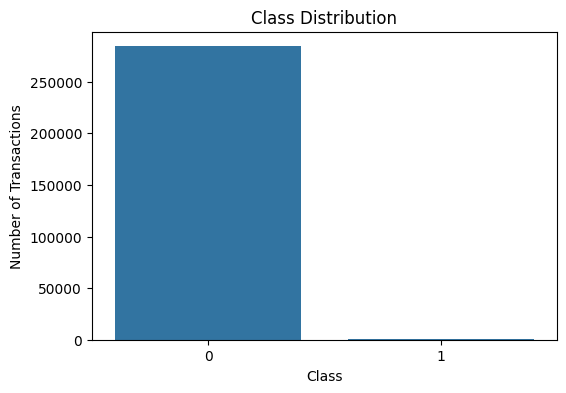

In [175]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")

plt.show()

In [176]:
legitimate = (df["Class"] == 0).sum()
fraud = (df["Class"] == 1).sum()

print("Legitimate:", legitimate)
print("Fraud:", fraud)
print("Fraud percentage:", fraud / len(df) * 100)

Legitimate: 284315
Fraud: 492
Fraud percentage: 0.1727485630620034


In [177]:
missing = df.isnull().sum()

print(missing[missing > 0])

Series([], dtype: int64)


In [178]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1081


In [179]:
duplicates = df[df.duplicated(keep=False)]

duplicates.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
32,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
33,26.0,-0.529912,0.873892,1.347247,0.145457,0.414209,0.100223,0.711206,0.176066,-0.286717,...,0.046949,0.208105,-0.185548,0.001031,0.098816,-0.552904,-0.073288,0.023307,6.14,0
34,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
35,26.0,-0.535388,0.865268,1.351076,0.147575,0.433680,0.086983,0.693039,0.179742,-0.285642,...,0.049526,0.206537,-0.187108,0.000753,0.098117,-0.553471,-0.078306,0.025427,1.77,0
112,74.0,1.038370,0.127486,0.184456,1.109950,0.441699,0.945283,-0.036715,0.350995,0.118950,...,0.102520,0.605089,0.023092,-0.626463,0.479120,-0.166937,0.081247,0.001192,1.18,0


In [180]:
df.dtypes

,0
Time,float64
V1,float64
V2,float64
V3,float64
V4,float64
V5,float64
V6,float64
V7,float64
V8,float64
V9,float64


In [181]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


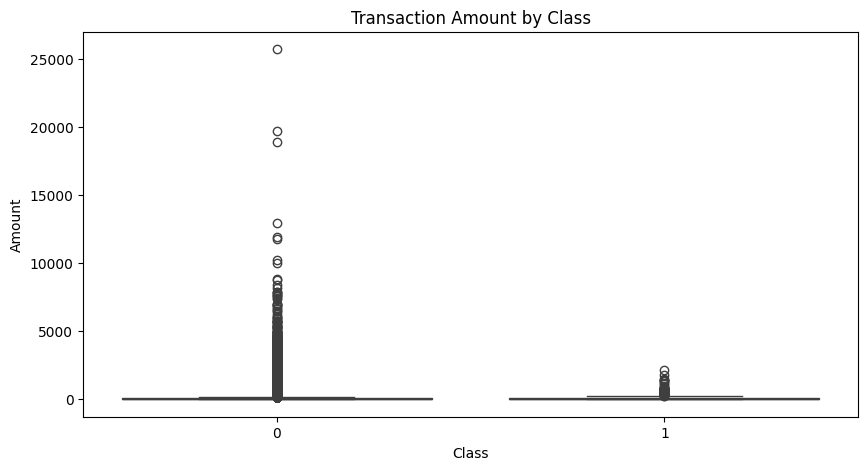

In [182]:
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class")
plt.ylabel("Amount")

plt.show()

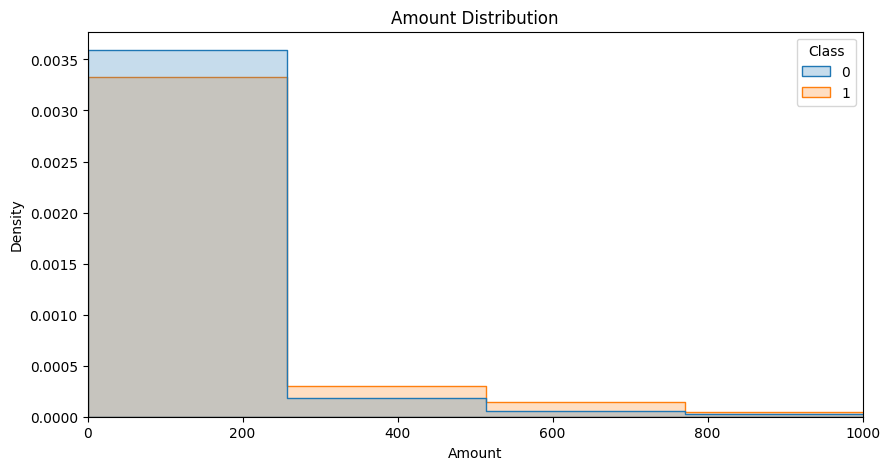

In [183]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=100,
    element="step",
    stat="density",
    common_norm=False
)

plt.xlim(0, 1000)

plt.title("Amount Distribution")
plt.show()

In [184]:
df["Hour"] = (
    (df["Time"] % 86400) // 3600
).astype(int)

df["Day_Index"] = (
    df["Time"] // 86400
).astype(int)

In [185]:
df.groupby("Hour")["Class"].mean()

,Class
Hour,
0,0.000780
1,0.002370
2,0.017127
3,0.004868
4,0.010412
5,0.003679
6,0.002195
7,0.003175
8,0.000876


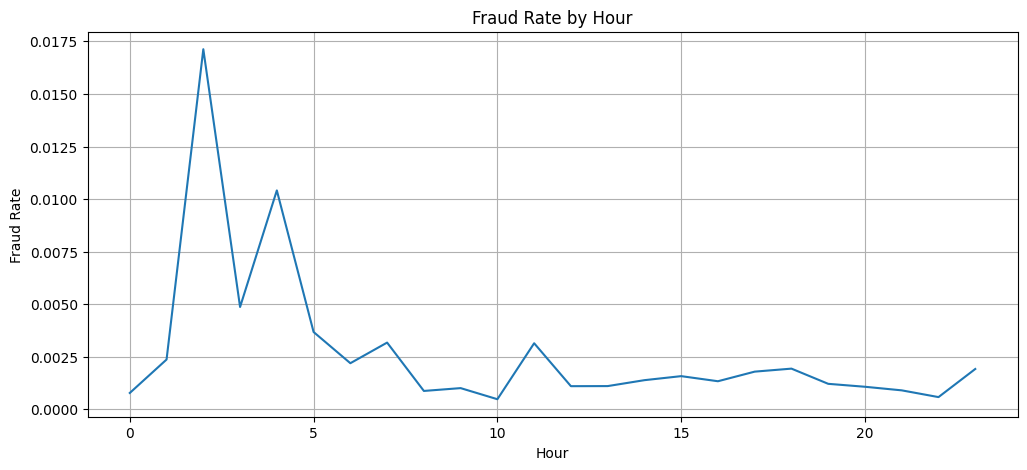

In [186]:
hourly_fraud = df.groupby("Hour")["Class"].mean()

plt.figure(figsize=(12, 5))

hourly_fraud.plot()

plt.title("Fraud Rate by Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate")

plt.grid()
plt.show()

In [187]:
df["Hour"] = ((df["Time"] % 86400) // 3600).astype(int)

df["Minute_of_Day"] = (
    (df["Time"] % 86400) // 60
).astype(int)

df["Day_Index"] = (
    df["Time"] // 86400
).astype(int)

In [188]:
df["Log_Amount"] = np.log1p(df["Amount"])

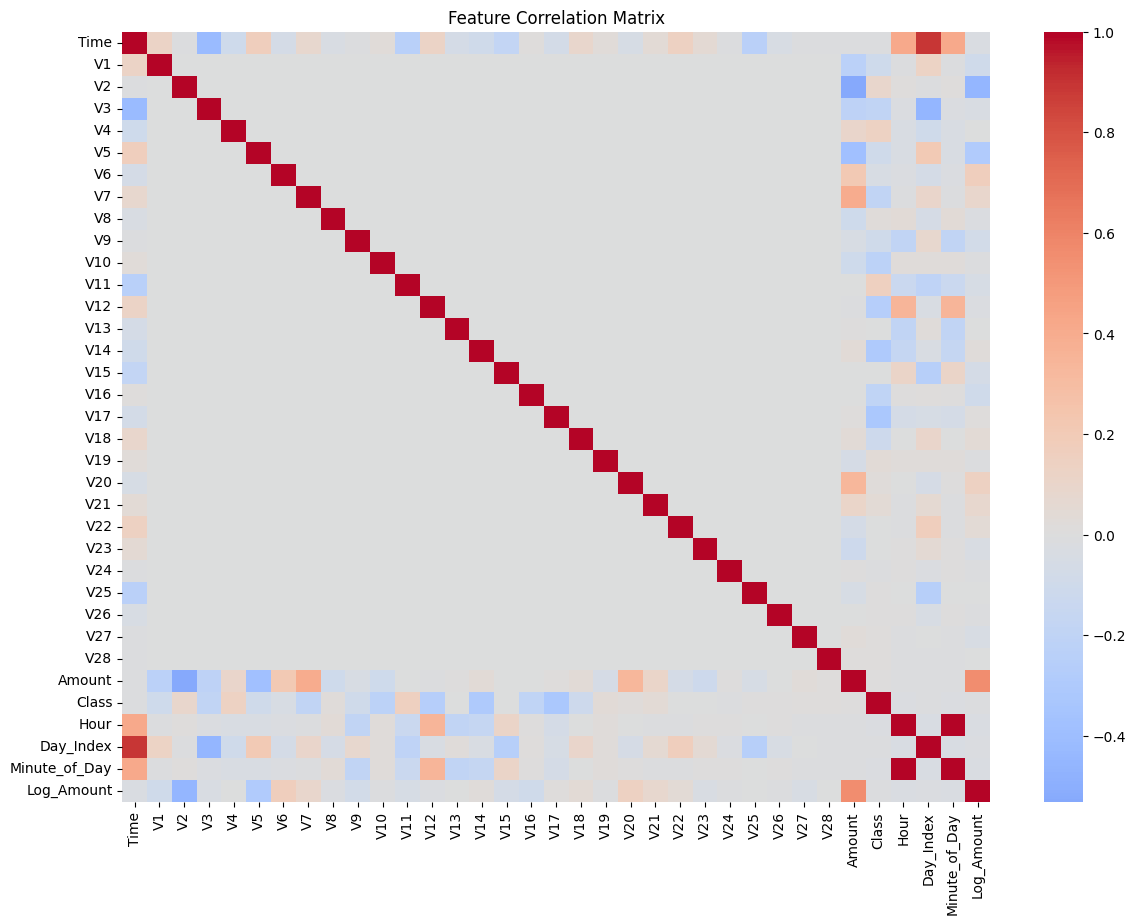

In [189]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

In [190]:
target = "Class"

features = [
    "Time",
    "Amount",
    "Hour",
    "Minute_of_Day",
    "Day_Index",
    "Log_Amount"
]

features += [
    f"V{i}" for i in range(1, 29)
]

X = df[features]
y = df[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (284807, 34)
y shape: (284807,)


In [191]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTrain fraud rate:")
print(y_train.mean())

print("\nTest fraud rate:")
print(y_test.mean())

Training: (227845, 34)
Testing: (56962, 34)

Train fraud rate:
0.001729245759178389

Test fraud rate:
0.0017204452090867595


In [192]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)

print("\nTrain fraud rate:")
print(y_train.mean())

print("\nTest fraud rate:")
print(y_test.mean())

Training: (227845, 34)
Testing: (56962, 34)

Train fraud rate:
0.001729245759178389

Test fraud rate:
0.0017204452090867595


In [193]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [194]:
baseline_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

start = time.time()

baseline_model.fit(
    X_train_scaled,
    y_train
)

training_time = time.time() - start

print(f"Training time: {training_time:.2f} seconds")

Training time: 2.04 seconds


In [195]:
y_pred = baseline_model.predict(X_test_scaled)

y_prob = baseline_model.predict_proba(
    X_test_scaled
)[:, 1]

In [196]:
print("Accuracy:",
      accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred, zero_division=0))

print("Recall:",
      recall_score(y_test, y_pred, zero_division=0))

print("F1:",
      f1_score(y_test, y_pred, zero_division=0))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob))

print("PR-AUC:",
      average_precision_score(y_test, y_prob))

Accuracy: 0.9991748885221726
Precision: 0.8311688311688312
Recall: 0.6530612244897959
F1: 0.7314285714285714
ROC-AUC: 0.9608397910374054
PR-AUC: 0.7379148205235506


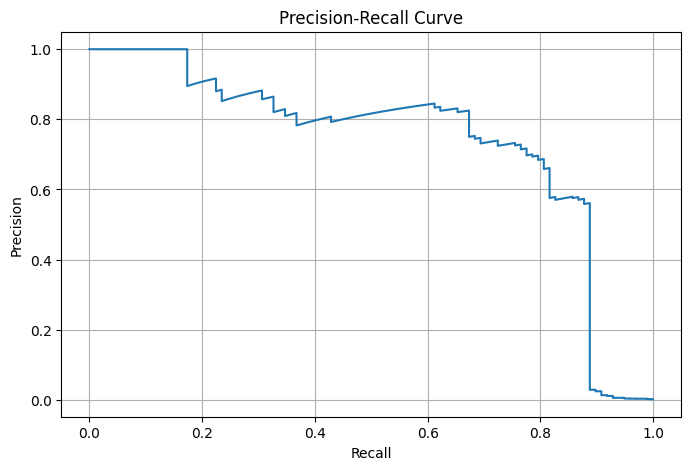

In [197]:
precision, recall, thresholds = precision_recall_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(8, 5))

plt.plot(
    recall,
    precision
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid()
plt.show()

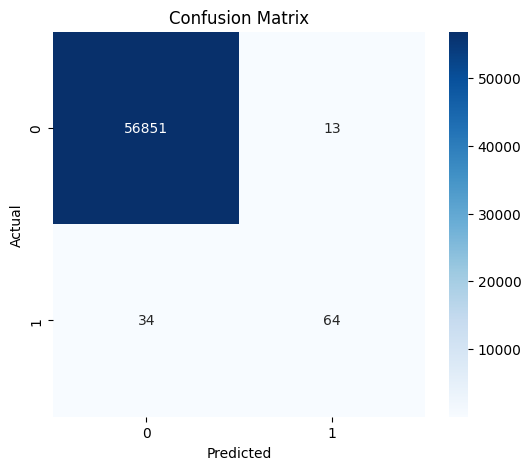

In [198]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [199]:
weighted_model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

weighted_model.fit(
    X_train_scaled,
    y_train
)

weighted_prob = weighted_model.predict_proba(
    X_test_scaled
)[:, 1]

In [200]:
weighted_pred = (
    weighted_prob >= 0.5
).astype(int)

print(
    classification_report(
        y_test,
        weighted_pred,
        zero_division=0
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        weighted_prob
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962

PR-AUC: 0.7224160073891958


In [201]:
smote = SMOTE(
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [202]:
smote_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

smote_prob = smote_model.predict_proba(
    X_test_scaled
)[:, 1]

smote_pred = (
    smote_prob >= 0.5
).astype(int)

In [203]:
print(
    classification_report(
        y_test,
        smote_pred,
        zero_division=0
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        smote_prob
    )
)

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.92      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.54     56962
weighted avg       1.00      0.97      0.98     56962

PR-AUC: 0.7321297764531739


In [204]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

start = time.time()

rf_model.fit(
    X_train,
    y_train
)

rf_time = time.time() - start

rf_prob = rf_model.predict_proba(
    X_test
)[:, 1]

rf_pred = (
    rf_prob >= 0.5
).astype(int)

In [205]:
print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

print(
    "PR-AUC:",
    average_precision_score(
        y_test,
        rf_prob
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.84      0.80      0.82        98

    accuracy                           1.00     56962
   macro avg       0.92      0.90      0.91     56962
weighted avg       1.00      1.00      1.00     56962

PR-AUC: 0.843752957471166


In [206]:
from xgboost import XGBClassifier

In [207]:
scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(scale_pos_weight)

577.2868020304569


In [208]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

start = time.time()

xgb_model.fit(
    X_train,
    y_train
)

xgb_time = time.time() - start

xgb_prob = xgb_model.predict_proba(
    X_test
)[:, 1]

xgb_pred = (
    xgb_prob >= 0.5
).astype(int)

In [209]:
models = {
    "Logistic Regression": (
        y_pred,
        y_prob
    ),
    "Class Weighted LR": (
        weighted_pred,
        weighted_prob
    ),
    "SMOTE LR": (
        smote_pred,
        smote_prob
    ),
    "Random Forest": (
        rf_pred,
        rf_prob
    ),
    "XGBoost": (
        xgb_pred,
        xgb_prob
    )
}

In [210]:
results = []

for name, (pred, prob) in models.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(
            y_test,
            pred
        ),
        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        ),
        "PR-AUC": average_precision_score(
            y_test,
            prob
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            prob
        )
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "PR-AUC",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC
4,XGBoost,0.999280,0.761468,0.846939,0.801932,0.866859,0.983368
3,Random Forest,0.999386,0.838710,0.795918,0.816754,0.843753,0.984459
0,Logistic Regression,0.999175,0.831169,0.653061,0.731429,0.737915,0.960840
2,SMOTE LR,0.972297,0.054217,0.918367,0.102389,0.732130,0.973558
1,Class Weighted LR,0.973667,0.056329,0.908163,0.106079,0.722416,0.973346


In [211]:
threshold_results = []

for threshold in np.arange(
    0.01,
    0.51,
    0.01
):

    pred = (
        xgb_prob >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            pred,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df.head()

,Threshold,Precision,Recall,F1
0,0.01,0.098793,0.918367,0.178394
1,0.02,0.159498,0.908163,0.271341
2,0.03,0.217822,0.897959,0.350598
3,0.04,0.268293,0.897959,0.413146
4,0.05,0.312057,0.897959,0.463158


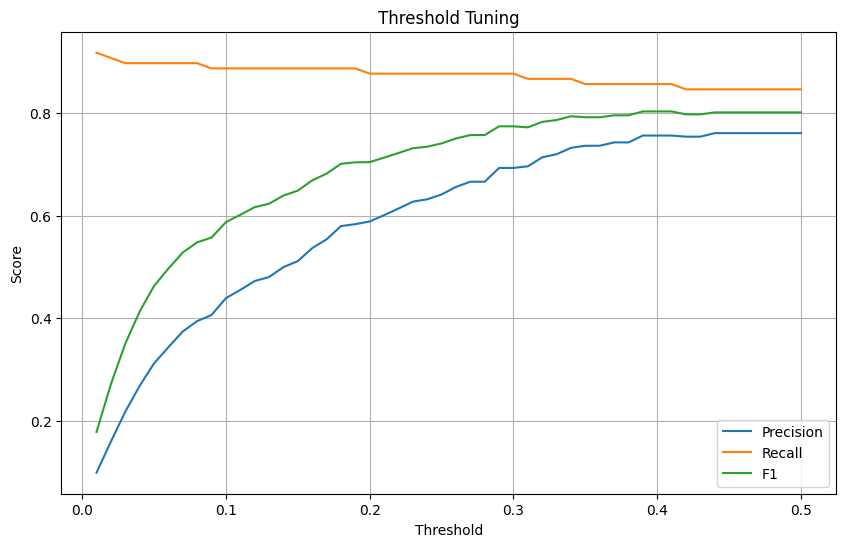

In [212]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning")

plt.legend()
plt.grid()

plt.show()

In [213]:
best_row = threshold_df.loc[
    threshold_df["F1"].idxmax()
]

print(best_row)

Threshold    0.390000
Precision    0.756757
Recall       0.857143
F1           0.803828
Name: 38, dtype: float64


In [214]:
best_threshold = best_row["Threshold"]

print(
    "Selected threshold:",
    best_threshold
)

Selected threshold: 0.39


In [215]:
test_results = X_test.copy()

test_results["Actual_Fraud"] = y_test.values

test_results["Fraud_Probability"] = xgb_prob

test_results["Risk_Score"] = (
    xgb_prob * 100
)

test_results["Flag"] = (
    xgb_prob >= best_threshold
).astype(int)

In [216]:
investigator_queue = test_results.sort_values(
    "Fraud_Probability",
    ascending=False
)

investigator_queue.head(20)

,Time,Amount,Hour,Minute_of_Day,Day_Index,Log_Amount,V1,V2,V3,V4,...,V23,V24,V25,V26,V27,V28,Actual_Fraud,Fraud_Probability,Risk_Score,Flag
42769,41237.0,118.30,11,687,0,4.781641,-10.281784,6.302385,-13.271718,8.925115,...,0.042805,0.478279,0.157771,0.329901,0.163504,-0.485552,1,0.999967,99.996674,1
142405,84694.0,12.31,23,1411,0,2.588516,-4.868108,1.264420,-5.167885,3.193648,...,0.629307,-0.168432,0.443744,0.276539,1.441274,-0.127944,1,0.999960,99.995956,1
204064,135095.0,345.00,13,811,1,5.846439,0.232512,0.938944,-4.647780,3.079844,...,0.999394,0.901260,-0.452093,0.192959,0.180859,-0.029315,1,0.999959,99.995895,1
77682,57163.0,1.00,15,952,0,0.693147,-10.363049,4.543672,-9.795898,5.508003,...,0.977178,-0.543369,-0.289125,-0.107586,0.330642,0.163577,1,0.999959,99.995872,1
150663,93853.0,316.06,2,124,1,5.759091,-5.839192,7.151532,-12.816760,7.031115,...,0.530481,0.472670,-0.275998,0.282435,0.104886,0.254417,1,0.999957,99.995682,1
102442,68207.0,1.00,18,1136,0,0.693147,-13.192671,12.785971,-9.906650,3.320337,...,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1,0.999956,99.995575,1
102444,68207.0,1.00,18,1136,0,0.693147,-13.192671,12.785971,-9.906650,3.320337,...,5.303607,-0.639435,0.263203,-0.108877,1.269566,0.939407,1,0.999956,99.995575,1
143336,85285.0,252.92,23,1421,0,5.537019,-6.713407,3.921104,-9.746678,5.148263,...,0.127214,-0.339450,0.394096,1.075295,1.649906,-0.394905,1,0.999952,99.995193,1
243749,152058.0,1.00,18,1094,1,0.693147,-3.576362,3.299436,-7.460433,7.783634,...,0.379249,-0.616962,-0.442811,0.359841,-2.651825,0.422184,1,0.999949,99.994934,1
229712,146022.0,1.18,16,993,1,0.779325,0.908637,2.849024,-5.647343,6.009415,...,-0.080006,-0.168597,0.465058,0.210510,0.648705,0.360224,1,0.999948,99.994812,1


In [217]:
def risk_category(probability):

    if probability >= 0.80:
        return "Critical"

    elif probability >= 0.50:
        return "High"

    elif probability >= 0.20:
        return "Medium"

    else:
        return "Low"


investigator_queue["Risk_Level"] = (
    investigator_queue[
        "Fraud_Probability"
    ].apply(risk_category)
)

In [218]:
importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

importance_df.head(15)

,Feature,Importance
19,V14,0.162866
15,V10,0.114261
17,V12,0.111051
9,V4,0.105668
22,V17,0.087283
16,V11,0.065268
8,V3,0.045585
21,V16,0.044451
12,V7,0.032706
7,V2,0.026704


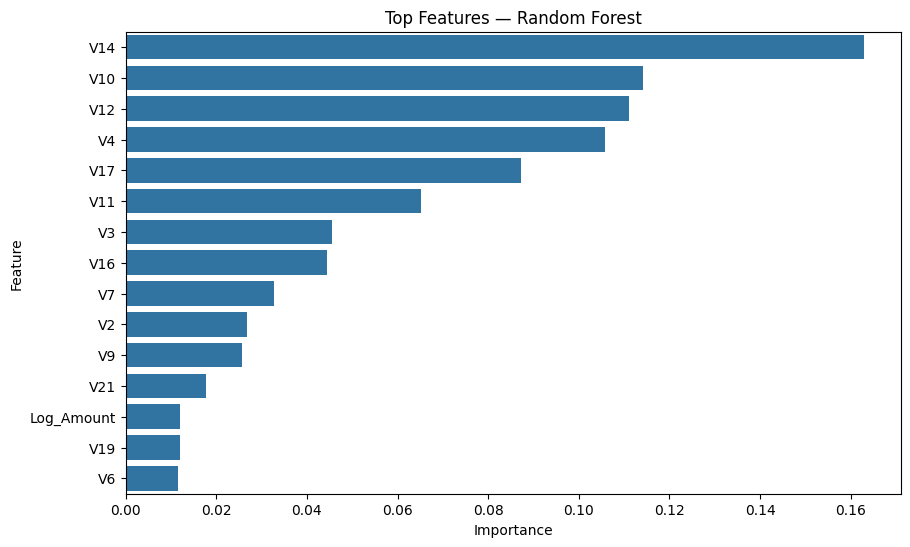

In [219]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance_df.head(15),
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features — Random Forest"
)

plt.show()

In [220]:
import shap

explainer = shap.TreeExplainer(
    xgb_model
)

In [221]:
X_sample = X_test.sample(
    1000,
    random_state=42
)

shap_values = explainer.shap_values(
    X_sample
)

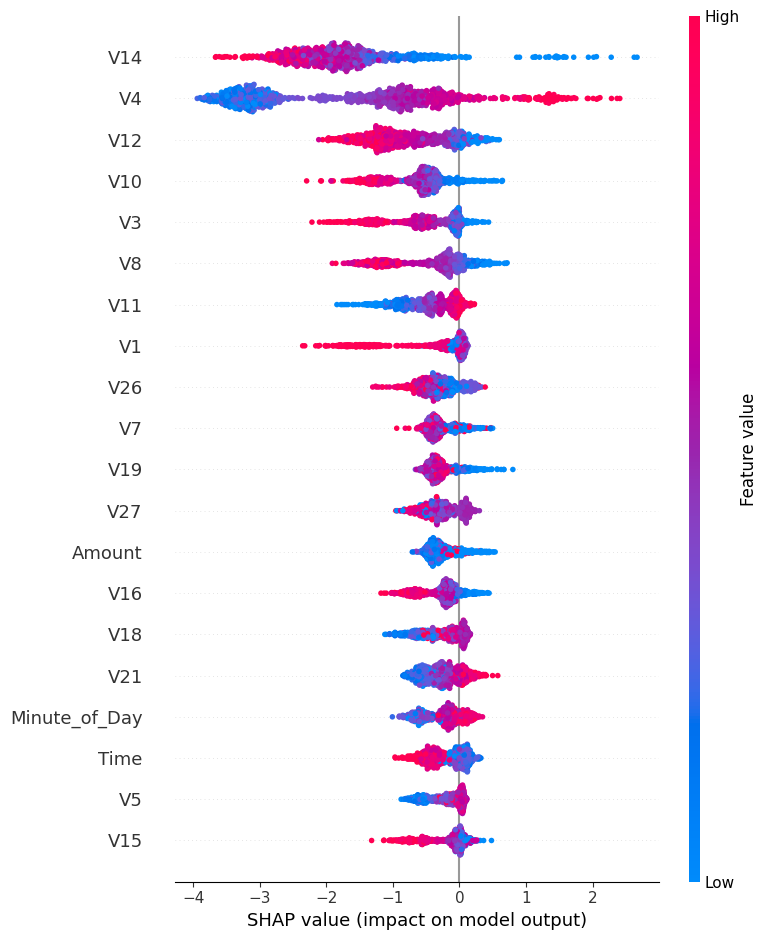

In [222]:
shap.summary_plot(
    shap_values,
    X_sample
)

In [223]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

cluster_features = [
    "Amount",
    "Time"
]

X_cluster = df[
    cluster_features
].copy()

cluster_scaler = StandardScaler()

X_cluster_scaled = cluster_scaler.fit_transform(
    X_cluster
)

In [224]:
inertias = []

for k in range(2, 8):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    km.fit(X_cluster_scaled)

    inertias.append(
        km.inertia_
    )

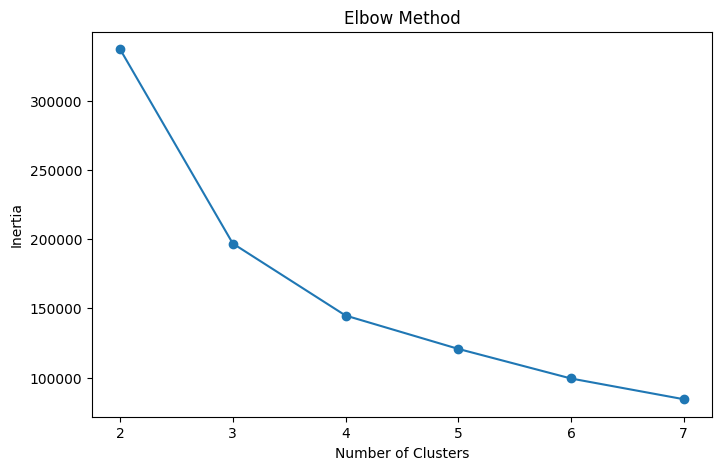

In [225]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 8),
    inertias,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [226]:
iso_model = IsolationForest(
    contamination=0.002,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_train)

IsolationForest(contamination=0.002, n_jobs=-1, random_state=42)

In [227]:
anomaly_pred = iso_model.predict(
    X_test
)

anomaly_pred = np.where(
    anomaly_pred == -1,
    1,
    0
)

In [228]:
print(
    classification_report(
        y_test,
        anomaly_pred,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.27      0.33      0.30        98

    accuracy                           1.00     56962
   macro avg       0.64      0.66      0.65     56962
weighted avg       1.00      1.00      1.00     56962



In [229]:
os.makedirs(
    "finguard_artifacts",
    exist_ok=True
)

In [230]:
joblib.dump(
    xgb_model,
    "finguard_artifacts/fraud_model.pkl"
)

['finguard_artifacts/fraud_model.pkl']

In [231]:
joblib.dump(
    scaler,
    "finguard_artifacts/scaler.pkl"
)

['finguard_artifacts/scaler.pkl']

In [232]:
joblib.dump(
    best_threshold,
    "finguard_artifacts/threshold.pkl"
)

['finguard_artifacts/threshold.pkl']

In [233]:
joblib.dump(
    features,
    "finguard_artifacts/features.pkl"
)

['finguard_artifacts/features.pkl']

In [234]:
investigator_queue.to_csv(
    "finguard_artifacts/investigator_queue.csv",
    index=False
)

In [235]:
results_df.to_csv(
    "finguard_artifacts/model_results.csv",
    index=False
)

In [236]:
!zip -r finguard_artifacts.zip finguard_artifacts

updating: finguard_artifacts/ (stored 0%)
updating: finguard_artifacts/threshold.pkl (deflated 11%)
updating: finguard_artifacts/model_results.csv (deflated 42%)
updating: finguard_artifacts/investigator_queue.csv (deflated 55%)
updating: finguard_artifacts/features.pkl (deflated 40%)
updating: finguard_artifacts/scaler.pkl (deflated 22%)
updating: finguard_artifacts/fraud_model.pkl (deflated 69%)


In [237]:
from google.colab import files

files.download(
    "finguard_artifacts.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [238]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [239]:
def chunk_text(
    text,
    chunk_size=800,
    overlap=100
):

    chunks = []

    start = 0

    while start < len(text):

        end = start + chunk_size

        chunks.append(
            text[start:end]
        )

        start = end - overlap

    return chunks

In [240]:
import faiss

In [243]:
'''                    FIN GUARD
                        │
          ┌─────────────┼─────────────┐
          │             │             │
          ↓             ↓             ↓
      Fraud Model   Segmentation    RAG
          │             │             │
          ↓             ↓             ↓
    Risk Score       Persona      Policy
          │             │          Search
          └─────────────┼─────────────┘
                        ↓
                  AI Assistant
                        │
              ┌─────────┴─────────┐
              ↓                   ↓
        Policy Retrieval    History Tool
              ↓                   ↓
              └─────────┬─────────┘
                        ↓
                 Case Summary
                        ↓
                  Recommendation              '''

'                    FIN GUARD\n                        │\n          ┌─────────────┼─────────────┐\n          │             │             │\n          ↓             ↓             ↓\n      Fraud Model   Segmentation    RAG\n          │             │             │\n          ↓             ↓             ↓\n    Risk Score       Persona      Policy\n          │             │          Search\n          └─────────────┼─────────────┘\n                        ↓\n                  AI Assistant\n                        │\n              ┌─────────┴─────────┐\n              ↓                   ↓\n        Policy Retrieval    History Tool\n              ↓                   ↓\n              └─────────┬─────────┘\n                        ↓\n                 Case Summary\n                        ↓\n                  Recommendation              '